# Demand Forecasting for ZPOTS

**Goal:** predict how many bookings a court will receive in a given hour, so the owner dashboard can show a 7-day demand heatmap.

**Why this matters:** if we know which slots will be hot, owners can:
- raise prices on peak slots
- run promotions on dead slots
- spot demand surges before the customer feels them

**The ML task:** *time-series regression* — input = features describing a court-hour, output = a number (predicted bookings).

## 1. Load the data

Each row is one (court, hour) over the last 12 weeks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/bookings.csv", parse_dates=["timestamp"])
print(f"Rows: {len(df):,}")
df.head()

Rows: 7,566


,timestamp,court_id,sport,district,day_of_week,hour,is_weekend,is_holiday,weather,price,n_courts,bookings
0,2026-02-10 10:00:00,bbc-01,Badminton,Sukhumvit,1,10,False,False,rainy,450,4,0
1,2026-02-10 11:00:00,bbc-01,Badminton,Sukhumvit,1,11,False,False,rainy,450,4,1
2,2026-02-10 12:00:00,bbc-01,Badminton,Sukhumvit,1,12,False,False,rainy,450,4,1
3,2026-02-10 13:00:00,bbc-01,Badminton,Sukhumvit,1,13,False,False,rainy,450,4,1
4,2026-02-10 14:00:00,bbc-01,Badminton,Sukhumvit,1,14,False,False,rainy,450,4,1


In [2]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,7566,NaN,NaN,NaN,2026-03-24 07:00:08.564631296,2026-02-10 10:00:00,2026-03-03 10:00:00,2026-03-24 10:00:00,2026-04-14 10:00:00,2026-05-05 10:00:00,NaN
court_id,7566,6,bbc-01,1261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sport,7566,4,Badminton,2522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,7566,3,Sukhumvit,3783,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,7566.0,NaN,NaN,NaN,2.998414,0.0,1.0,3.0,5.0,6.0,2.000132
hour,7566.0,NaN,NaN,NaN,14.996035,8.0,11.0,15.0,19.0,22.0,4.321359
is_weekend,7566,2,False,5406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_holiday,7566,2,False,7188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather,7566,3,sunny,3978,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,7566.0,NaN,NaN,NaN,816.038858,350.0,550.0,800.0,1100.0,1800.0,367.843465


## 2. What does the data look like?

Before any modeling, **always look at the data**. We're hunting for patterns
the model will need to learn — and for surprises.

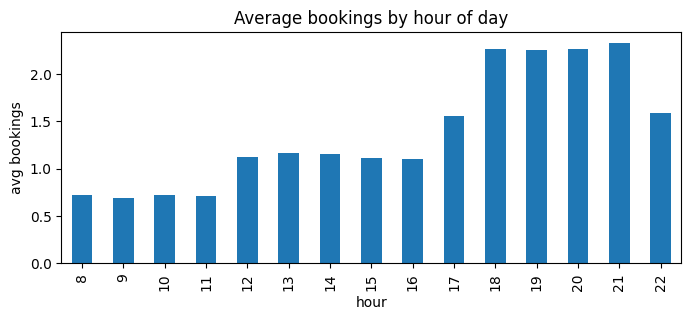

In [3]:
hourly = df.groupby("hour")["bookings"].mean()
hourly.plot(kind="bar", figsize=(8,3), title="Average bookings by hour of day")
plt.ylabel("avg bookings"); plt.xlabel("hour"); plt.show()

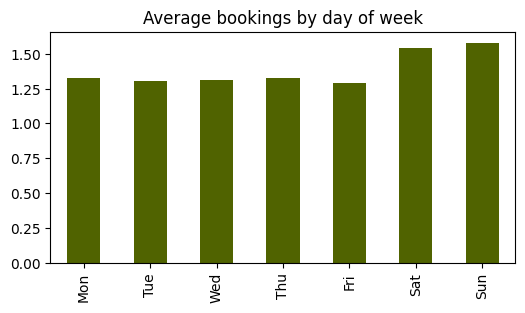

In [4]:
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
daily = df.groupby("day_of_week")["bookings"].mean()
daily.index = dow_labels
daily.plot(kind="bar", figsize=(6,3), title="Average bookings by day of week", color="#506300")
plt.show()

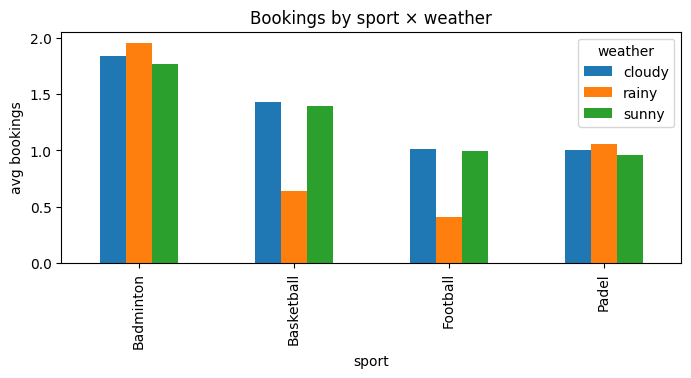

In [5]:
df.groupby(["sport","weather"])["bookings"].mean().unstack().plot(
    kind="bar", figsize=(8,3), title="Bookings by sport × weather"
)
plt.ylabel("avg bookings"); plt.show()

**What we see:**
- Big evening peak (18–21h)
- Weekends slightly lower on average (the *evening peak* is what drives demand, not the day)
- Football and Basketball drop hard on rainy days — **weather matters for outdoor sports**

These are exactly the patterns we expect a model to capture.

## 3. Feature engineering

A model can't read words like "Sunday" or "rainy". We need numbers.

**One-hot encoding** turns one categorical column into many 0/1 columns —
one per category. We use `pd.get_dummies` for this.

We also add **lag features**: "how many bookings did this same court see at this hour *yesterday*?"
For time series, the recent past is often the strongest predictor.

In [6]:
# Sort so lag features are well-defined
df = df.sort_values(["court_id", "timestamp"]).reset_index(drop=True)

# Lag: same court, 24 hours ago
df["bookings_lag_24h"] = df.groupby("court_id")["bookings"].shift(24).fillna(0)

# One-hot encode categoricals
features = pd.get_dummies(
    df[["court_id","sport","district","day_of_week","hour",
        "is_weekend","is_holiday","weather","price","n_courts","bookings_lag_24h"]],
    columns=["court_id","sport","district","weather"],
    drop_first=True,
)
target = df["bookings"]

print("Feature matrix shape:", features.shape)
features.head()

Feature matrix shape: (7566, 19)


,day_of_week,hour,is_weekend,is_holiday,price,n_courts,bookings_lag_24h,court_id_dwn-03,court_id_imp-06,court_id_pdl-04,court_id_ryl-05,court_id_sky-02,sport_Basketball,sport_Football,sport_Padel,district_Sukhumvit,district_Thong Lor,weather_rainy,weather_sunny
0,1,10,False,False,450,4,0.0,False,False,False,False,False,False,False,False,True,False,True,False
1,1,11,False,False,450,4,0.0,False,False,False,False,False,False,False,False,True,False,True,False
2,1,12,False,False,450,4,0.0,False,False,False,False,False,False,False,False,True,False,True,False
3,1,13,False,False,450,4,0.0,False,False,False,False,False,False,False,False,True,False,True,False
4,1,14,False,False,450,4,0.0,False,False,False,False,False,False,False,False,True,False,True,False


## 4. Train/test split

For most ML problems we shuffle the data and split randomly. **Not for time series.**
If we randomly mix past and future rows, the model "cheats" — it learns from
tomorrow to predict today. That looks great in evaluation and fails in production.

We split **chronologically**: first 80% of time → train, last 20% → test.

In [7]:
split_idx = int(len(df) * 0.80)
X_train, X_test = features.iloc[:split_idx], features.iloc[split_idx:]
y_train, y_test = target.iloc[:split_idx], target.iloc[split_idx:]

print(f"Train: {len(X_train):,} rows, Test: {len(X_test):,} rows")
print(f"Train period: {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[split_idx-1]}")
print(f"Test  period: {df['timestamp'].iloc[split_idx]} → {df['timestamp'].iloc[-1]}")

Train: 6,052 rows, Test: 1,514 rows
Train period: 2026-02-10 10:00:00 → 2026-04-18 12:00:00
Test  period: 2026-04-18 13:00:00 → 2026-05-05 10:00:00
